In [2]:
import pandas as pd

df = pd.read_csv("mariokart.csv")
df.head()

,id,duration,n_bids,cond,start_pr,ship_pr,total_pr,ship_sp,seller_rate,stock_photo,wheels,title
0,150377422259,3,20,new,0.99,4.00,51.55,standard,1580,yes,1,~~ Wii MARIO KART &amp; WHEEL ~ NINTENDO Wii ~...
1,260483376854,7,13,used,0.99,3.99,37.04,firstClass,365,yes,1,Mariokart Wii Nintendo with wheel - Mario Kart...
2,320432342985,3,16,new,0.99,3.50,45.50,firstClass,998,no,1,Mario Kart Wii (Wii)
3,280405224677,3,18,new,0.99,0.00,44.00,standard,7,yes,1,Brand New Mario Kart Wii Comes with Wheel. Fre...
4,170392227765,1,20,new,0.01,0.00,71.00,media,820,yes,2,BRAND NEW NINTENDO 1 WII MARIO KART WITH 2 WHE...


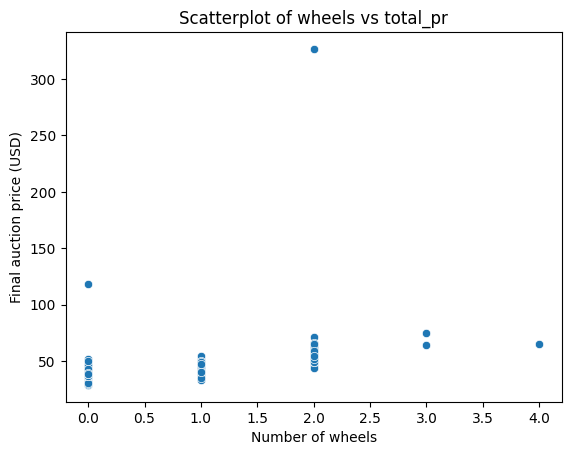

<Figure size 640x480 with 0 Axes>

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='wheels', y='total_pr')
plt.xlabel("Number of wheels")
plt.ylabel("Final auction price (USD)")
plt.title("Scatterplot of wheels vs total_pr")
plt.show()
plt.savefig("scatter_wheels_totalpr.png", dpi=300, bbox_inches='tight')

In [4]:
import statsmodels.formula.api as smf

model1 = smf.ols('total_pr ~ wheels', data=df).fit()
model1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               total_pr   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     17.23
Date:                Fri, 22 May 2026   Prob (F-statistic):           5.70e-05
Time:                        10:07:04   Log-Likelihood:                -658.35
No. Observations:                 143   AIC:                             1321.
Df Residuals:                     141   BIC:                             1327.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.4052      3.433     11.188      0.000      31.619      45.192
wheels        10.0059      2.411      4.151      0.000       5.240      14.771
==============================================================================
Omnibus:                      281.585   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            66481.291
Skew:                           9.792   Prob(JB):                         0.00
Kurtosis:                     106.799   Cond. No.                         3.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
import statsmodels.formula.api as smf

df['cond'] = df['cond'].astype('category')
df['stock_photo'] = df['stock_photo'].astype('category')

model2 = smf.ols('total_pr ~ cond + stock_photo + duration + wheels', data=df).fit()
model2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               total_pr   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     4.860
Date:                Fri, 22 May 2026   Prob (F-statistic):            0.00107
Time:                        10:07:04   Log-Likelihood:                -657.17
No. Observations:                 143   AIC:                             1324.
Df Residuals:                     138   BIC:                             1339.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             43.5201      8.370      5.199      0.000      26.970      60.070
cond[T.used]          -2.5816      5.227     -0.494      0.622     -12.917       7.754
stock_photo[T.yes]    -6.7542      5.173     -1.306      0.194     -16.983       3.474
duration               0.3788      0.939      0.403      0.687      -1.477       2.235
wheels                 9.9476      2.718      3.659      0.000       4.572      15.323
==============================================================================
Omnibus:                      276.313   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            60758.374
Skew:                           9.447   Prob(JB):                         0.00
Kurtosis:                     102.198   Cond. No.                         23.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

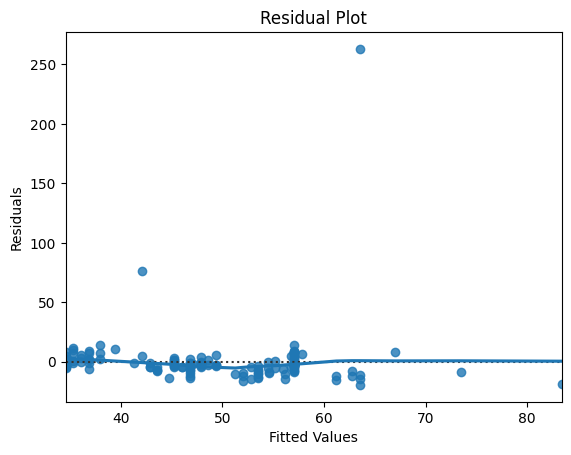

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.residplot(x=model2.fittedvalues, y=model2.resid, lowess=True)
plt.title("Residual Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.savefig("residplot.png", dpi=300, bbox_inches='tight')
plt.show()

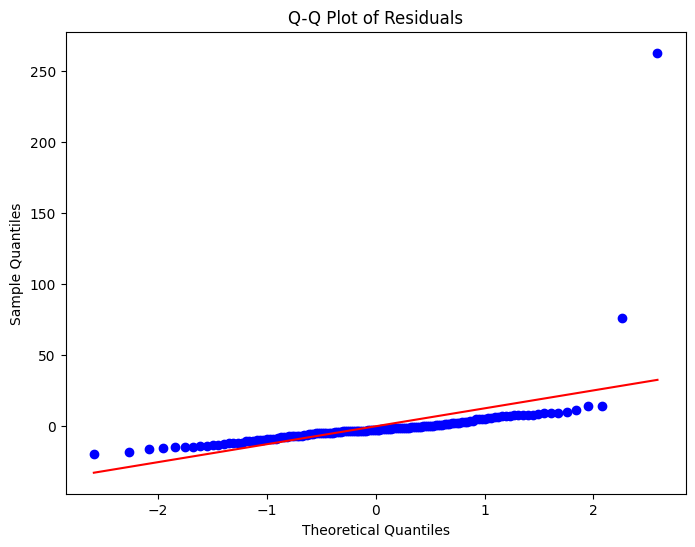

In [10]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import scipy.stats as stats # Import scipy.stats

df = pd.read_csv("mariokart.csv")

model2 = smf.ols('total_pr ~ cond + stock_photo + duration + wheels', data=df).fit()

plt.figure(figsize=(8,6))
stats.probplot(model2.resid, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.savefig("qqplot_residuals.png", dpi=300, bbox_inches='tight')

plt.show()